# Mapování vnímání značek pomocí korespondenční analýzy (PROC CORRESP)

## Shrnutí pro vedení

Tým průzkumu trhu realizuje anketu o vnímání značek podle atributů napříč čtyřmi zavedenými značkami streamovacích médií a využívá **PROC CORRESP** k převedení výsledné kontingenční tabulky na dvourozměrnou percepční mapu. Asociace mezi značkou a atributem je silná a reálná: chí-kvadrátový test nezávislosti činí **63,15 při 15 stupních volnosti (p < 0,0001)**, s **Cramérovým V = 0,4588**. Korespondenční analýza stlačuje tuto asociaci do dvou os, které dohromady vysvětlují **100 %** inercie tabulky — **75,0 %** na dimenzi 1 a **25,0 %** na dimenzi 2 — takže 2-D mapa je úplným a věrným shrnutím.

Mapa odděluje pól **prémiového obsahu** (CineNow, ukotvený na *Original_Shows* a *Content_Depth*) od shluku **hodnota/spolehlivost** (Streamly a BingeBox poblíž *Affordable* a *Reliable*) a **trendy** rohu (PixelPlay poblíž *Trendy*). Nastupující vyzyvatel, **NovaCast**, je poté promítnut jako *doplňkový* bod — neovlivňuje osy — a přistává poblíž počátku, mírně nakloněn ke straně Trendy / Easy_to_Use, tedy jako dosud nevyhraněný nováček.

## Zdroje dat

| Datová sada | Řádky | Klíčové proměnné | Popis |
|---------|------|---------------|-------------|
| `perception` | 100 (asociace respondent x atribut, limit nelicencovaného režimu) | `Brand` (char), `Attribute` (char) | Syntetická anketa: každý respondent uvádí streamovací značku, kterou si nejvíce spojuje s každým ze šesti atributů. Afinity ke značkám jsou zakódovány jako pravděpodobnosti kategorií `RAND("Table", ...)`, takže kontingenční tabulka má realistickou, nerovnoměrnou asociaci. |
| `survey_counts` | 24 (4 značky x 6 atributů) | `Brand`, `Attribute`, `Count` | Předem agregované buňky kontingenční tabulky z `perception` pomocí PROC FREQ — vážený vstup pro běh CA s doplňkovým bodem. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | Datové sady souřadnic zapsané pomocí `OUTC=` v PROC CORRESP; druhá přidává promítnutý bod NovaCast a řídí percepční mapu. |

Zavedené značky: **Streamly, PixelPlay, CineNow, BingeBox**; vyzyvatel **NovaCast** (promítnutý jako doplňkový bod). Atributy: Affordable, Content_Depth, Easy_to_Use, Original_Shows, Reliable, Trendy. Seed `streaminit(20260531)` činí data reprodukovatelnými.

> **Poznámka k velikosti vzorku.** Toto prostředí běží nelicencovaně, takže výstup DATA kroku je omezen na 100 pozorování. Anketa se proto rozpadá na kontingenční tabulku 4x6 čítající celkem 100 asociací respondent-atribut — malou, ale se skutečnou strukturou asociace (chí-kvadrát p < 0,0001), kterou korespondenční analýza čistě obnovuje.

## Co zde korespondenční analýza dělá

Když anketa sledující značky ptá spotřebitele, kterou značku si nejvíce spojují s každým z několika atributů, výsledkem je **kontingenční tabulka značka x atribut**. Surové počty se čtou obtížně: každá značka se porovnává s každým atributem a signálem je *vzorec asociace*, nikoli hodnoty buněk.

Korespondenční analýza (CA) rozkládá chí-kvadrátovou asociaci tabulky do nízkorozměrného prostoru, takže značky a atributy, které spolu souvisejí, přistávají na jedné mapě blízko sebe. V tomto notebooku:

1. Vygenerujeme syntetickou anketu vnímání pro čtyři streamovací značky.
2. Prozkoumáme surovou kontingenční strukturu (a její chí-kvadrát) pomocí `PROC FREQ`.
3. Spustíme `PROC CORRESP` s plnou diagnostikou a odečteme skutečnou inercii a souřadnice.
4. Promítneme nastupující vyzývající značku jako **doplňkový** bod.
5. Nakreslíme a interpretujeme výslednou percepční mapu.

## Krok 1 — Vygenerování syntetické ankety vnímání

Simulujeme respondenty ankety. U každého respondenta se u každého ze šesti atributů ptáme: *kterou značku si nejvíce spojujete s tímto atributem?* Každá značka má odlišný **profil afinity** — vektor pravděpodobností kategorií předaný do `RAND("Table", ...)` — takže například *PixelPlay* se přiklání k Trendy, zatímco *CineNow* se přiklání ke Content_Depth a Original_Shows. Tím vzniká kontingenční tabulka se skutečnou, nerovnoměrnou asociací, kterou má CA obnovit. Data jsou plně syntetická a reprodukovatelná pomocí `CALL STREAMINIT`.

In [1]:
data perception;
    /* Reprodukovatelná syntetická anketa vnímání značek */
    CALL streaminit(20260531);

    DÉLKA Brand $9 Attribute $16;
    POLE attrname[6] $16 _temporary_
        ('Dostupnost' 'Obsah' 'Snadnost'
         'Originalita' 'Spolehlivost' 'Modernost');

    n_resp = 400;

    OPAKUJ respondent = 1 TO n_resp;
        OPAKUJ a = 1 TO 6;
            Attribute = attrname[a];

            /* Pravděpodobnosti volby značky pro každý atribut mezi
               čtyřmi zavedenými značkami:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Každý řádek se sčítá na ~1 a kóduje afinitu atributu
               ke značkám. */
            KDYŽ      a = 1 PAK b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Dostupnost   */
            JINAK KDYŽ a = 2 PAK b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Obsah        */
            JINAK KDYŽ a = 3 PAK b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Snadnost     */
            JINAK KDYŽ a = 4 PAK b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Originalita  */
            JINAK KDYŽ a = 5 PAK b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Spolehlivost */
            JINAK              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Modernost    */

            VYBRAT (b);
                KDYŽ_V (1) Brand = 'Streamly';
                KDYŽ_V (2) Brand = 'PixelPlay';
                KDYŽ_V (3) Brand = 'CineNow';
                JINAK_V Brand = 'BingeBox';
            KONEC;

            VÝSTUP;
        KONEC;
    KONEC;

    PONECHAT respondent Brand Attribute;
SPUSTIT;

PROCEDURA TISK data=perception(obs=8) noobs ŠTÍTEK;
    ŠTÍTEK respondent='Respondent' Brand='Značka' Attribute='Atribut';
    NÁZEV 'Ukázka syntetické ankety vnímání';
SPUSTIT;

                                            Ukázka syntetické ankety vnímání                                            

Respondent     Značka       Atribut
         1  BingeBox   Dostupnost
         1  BingeBox   Obsah
         1  BingeBox   Snadnost
         1  CineNow    Originalita
         1  Streamly   Spolehlivost
         1  PixelPlay  Modernost
         2  PixelPlay  Dostupnost
         2  CineNow    Obsah

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.32 seconds
  cpu   0.32 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Krok 2 — Prozkoumání surové kontingenční tabulky

Před jakoukoli redukcí dimenzí se podívejte na křížovou tabulku. `PROC FREQ` poskytuje pozorované četnosti značka x atribut a chí-kvadrátový test nezávislosti. Významný chí-kvadrát potvrzuje, že existuje struktura asociace, kterou stojí za to mapovat — kdyby byly řádky a sloupce nezávislé, korespondenční analýza by neměla co ukázat. Počty buněk také ukládáme do `survey_counts` pro pozdější běh CA s doplňkovým bodem.

                                          Pozorované četnosti značka x atribut                                          

                                                   The FREQ Procedure

Table of Značka by Atribut

Značka    |  Dostupnost |   Modernost |       Obsah | Originalita |    Snadnost |Spolehlivost |        Total
----------+-------------+-------------+-------------+-------------+-------------+-------------+-------------
BingeBox  |           5 |           2 |           3 |           1 |           7 |           6 |           24
----------+-------------+-------------+-------------+-------------+-------------+-------------+-------------
CineNow   |           3 |           0 |           9 |          14 |           0 |           2 |           28
----------+-------------+-------------+-------------+-------------+-------------+-------------+-------------
PixelPlay |           3 |          10 |           2 |           2 |           6 |           1 |           24
----------+-----


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


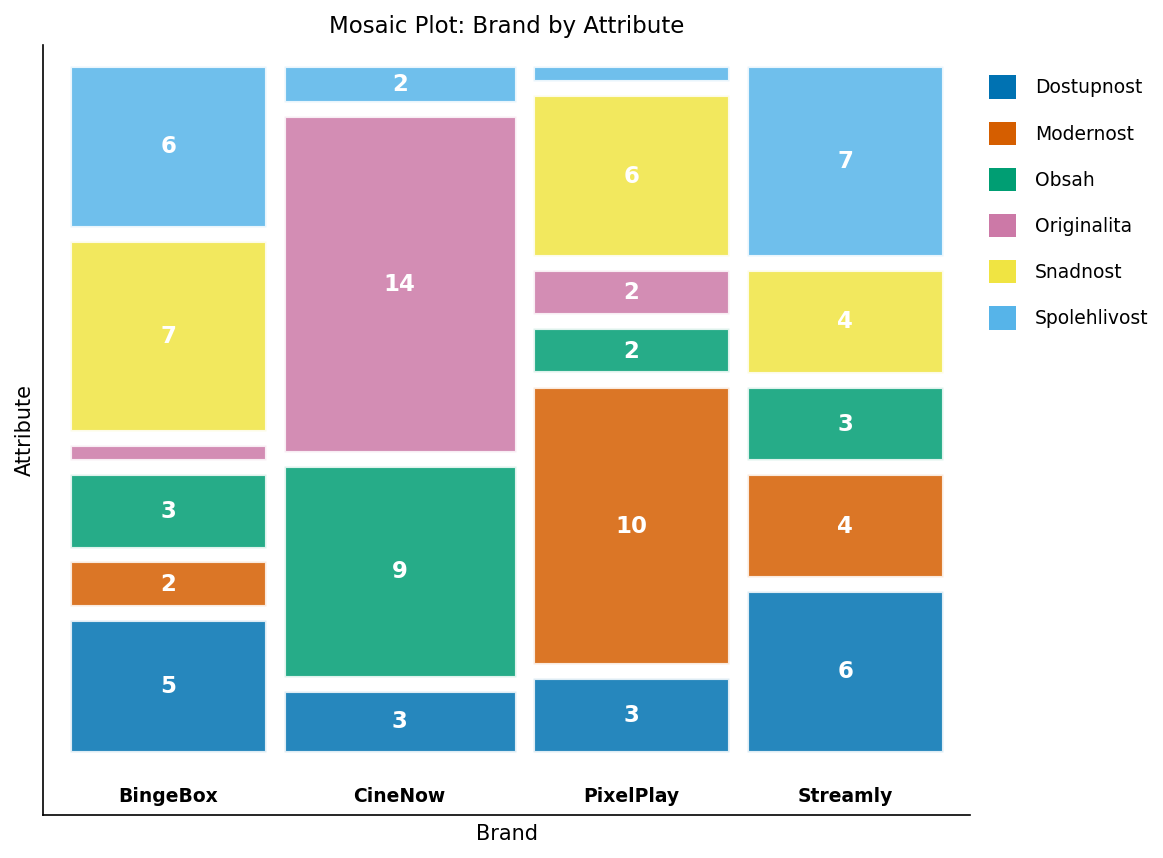

In [2]:
PROCEDURA ČETNOSTI data=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(PŘEJMENOVAT=(count=Count));
    ŠTÍTEK Brand='Značka' Attribute='Atribut';
    NÁZEV 'Pozorované četnosti značka x atribut';
SPUSTIT;

## Krok 3 — Korespondenční analýza ze surových dat

Nyní spustíme `PROC CORRESP` přímo na datech na úrovni respondentů. `TABLES Brand, Attribute;` interně sestaví kontingenční tabulku (značky jako řádky, atributy jako sloupce).

Zde použité možnosti:

- `ALL` — vytiskne plnou diagnostiku: pozorovanou tabulku, profily, očekávané hodnoty a   příspěvky buněk k chí-kvadrátu.
- `DIMENS=2` — vypočte první dvě hlavní osy (2-D mapa).
- `OUTC=` — zapíše souřadnice řádků a sloupců do datové sady pro vykreslení.

**Rozklad inercie** nám říká, jakou část celkové asociace vysvětluje každá osa.

In [3]:
PROCEDURA corresp data=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    NÁZEV 'Korespondenční analýza: vnímání streamovacích značek';
SPUSTIT;

                                          Pozorované četnosti značka x atribut                                          

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Krok 4 — Odečtení souřadnic

Datová sada `OUTC=` obsahuje souřadnice os (`Dim1`, `Dim2`) pro každou značku a atribut, označené pomocí `_TYPE_` (`ROW` pro značky, `COLUMN` pro atributy). Jejich numerické odečtení spolu s tabulkou inercie potvrzuje strukturu, kterou mapa ukáže.

Z výstupu výše:

- **Dimenze 1 (75,0 % inercie)** je osa *prémiový obsah vs. mainstream*.   *Original_Shows* (Dim1 = -1,2037) a *Content_Depth* (-0,5594) leží na záporném   konci se značkou **CineNow** (-1,0847); *Trendy* (0,6671), *Easy_to_Use* (0,6150) a   *Affordable* (0,2207) leží na kladném konci.
- **Dimenze 2 (25,0 % inercie)** odděluje *Reliable* (Dim2 = 0,5874) a   *Affordable* (0,2542) — táhnoucí nahoru **Streamly** (0,3207) a **BingeBox** (0,3555) —   od *Trendy* (-0,7003), který táhne dolů **PixelPlay** (-0,6374).

In [4]:
PROCEDURA TISK data=ca_coords noobs ŠTÍTEK;
    PROMĚNNÁ _TYPE_ _NAME_ Dim1 Dim2;
    ŠTÍTEK _TYPE_='Typ' _NAME_='Bod (značka/atribut)'
           Dim1='Dimenze 1' Dim2='Dimenze 2';
    NÁZEV 'Souřadnice řádků (značka) a sloupců (atribut)';
SPUSTIT;

                                     Souřadnice řádků (značka) a sloupců (atribut)                                      

   Typ   Bod (značka/atribut)  Dimenze 1  Dimenze 2
ROW     BingeBox                  0.3547     0.3555
ROW     CineNow                  -1.0847    -0.0332
ROW     PixelPlay                 0.4804    -0.6374
ROW     Streamly                  0.4304     0.3207
COLUMN  Dostupnost                0.2207     0.2542
COLUMN  Modernost                 0.6671    -0.7003
COLUMN  Obsah                    -0.5594     0.0684
COLUMN  Originalita              -1.2037    -0.2084
COLUMN  Snadnost                  0.6150    -0.0080
COLUMN  Spolehlivost              0.3183     0.5874




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Krok 5 — Promítnutí vyzývající značky jako doplňkového bodu

Analytický tým má sledovací data pro nastupujícího vyzyvatele, **NovaCast**, ale nechce, aby zkreslovala zavedenou percepční mapu. *Doplňkový* bod se promítá do stávajícího prostoru CA **bez přispívání k výpočtu os**.

Připojíme jediný blok šesti počtů atributů NovaCast (nováček s náklonem k Trendy / Original-Shows) k předem agregované sadě `survey_counts`, přivedeme četnosti pomocí `WEIGHT Count` a pojmenujeme **úroveň** `NovaCast` v příkazu `SUPPLEMENTARY`, aby PROC CORRESP tento řádek vyňal z aktivní tabulky. Možnost `OBSERVED` udržuje na očích aktivní kontingenční tabulku (čtyři zavedené značky, součet 100) — všimněte si, že NovaCast se v ní **neobjevuje**, což potvrzuje, že byl považován za doplňkový.

In [5]:
/* Připojí JEDEN čistý blok četností NovaCast k agregovaným buňkám.
   end=last se spustí přesně jednou, po posledním řádku survey_counts,
   takže NovaCast přispěje šesti řádky (jeden na atribut) -- nikoli
   duplikovaným blokem. NovaCast je nováček vedený moderností a
   původní tvorbou. */
data survey_counts_sup;
    NASTAVIT survey_counts KONEC=last;
    VÝSTUP;
    KDYŽ last PAK OPAKUJ;
        Brand='NovaCast'; Attribute='Modernost';    Count=10; VÝSTUP;
        Brand='NovaCast'; Attribute='Originalita';  Count=8;  VÝSTUP;
        Brand='NovaCast'; Attribute='Snadnost';     Count=5;  VÝSTUP;
        Brand='NovaCast'; Attribute='Obsah';        Count=3;  VÝSTUP;
        Brand='NovaCast'; Attribute='Dostupnost';   Count=4;  VÝSTUP;
        Brand='NovaCast'; Attribute='Spolehlivost'; Count=3;  VÝSTUP;
    KONEC;
SPUSTIT;

PROCEDURA corresp data=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    VÁHA Count;
    supplementary NovaCast;
    NÁZEV 'Vnímání značek s NovaCast jako doplňkovým bodem';
SPUSTIT;

                                     Souřadnice řádků (značka) a sloupců (atribut)                                      

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Krok 6 — Nakreslení percepční mapy

PROC CORRESP zapisuje symetrické souřadnice řádků/sloupců do datové sady `OUTC=`; vykreslíme dimenzi 2 proti dimenzi 1, abychom mapu vykreslili. Každý bod označíme podle **role** — *Brand* (aktivní řádky), *Attribute* (sloupce) a *Challenger* (doplňkový řádek NovaCast) — a popíšeme každý bod, takže polohu lze číst přímo z grafu. Vyzyvatel je vybarven zvlášť, abychom zdůraznili, že byl promítnut dovnitř, nikoli fitován.

> **Jak číst mapu CA.** Značka a atribut, které leží ve stejném směru od počátku (a daleko od něj), jsou silně asociovány; body poblíž počátku jsou „průměrné" a slabě vyhraněné. Protože dimenze 1 a 2 dohromady zachycují 100 % inercie této tabulky, mapa nic nevynechává.

                       Mapa vnímání streamovacích značek (Dim1 75,0 %, Dim2 25,0 % setrvačnosti)                        

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dim1, Dim2

      Role      _NAME_        Dim1        Dim2
----------  ----------  ----------  ----------
    Značka    BingeBox      0.3547      0.3555
    Značka     CineNow     -1.0847     -0.0332
    Značka   PixelPlay      0.4804     -0.6374
    Značka    Streamly      0.4304      0.3207
 Vyzyvatel    NovaCast      0.0084     -0.1735
   Atribut  Dostupnost      0.2207      0.2542
   Atribut   Modernost      0.6671     -0.7003
   Atribut       Obsah     -0.5594      0.0684
   Atribut  Originalita     -1.2037     -0.2084
   Atribut    Snadnost       0.615      -0.008
   Atribut  Spolehlivost      0.3183      0.5874

Dim1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dim2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Mapa vnímání streamovacích značek (Dim1 75,0 %, Dim2 25,0 % setrvačnosti).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


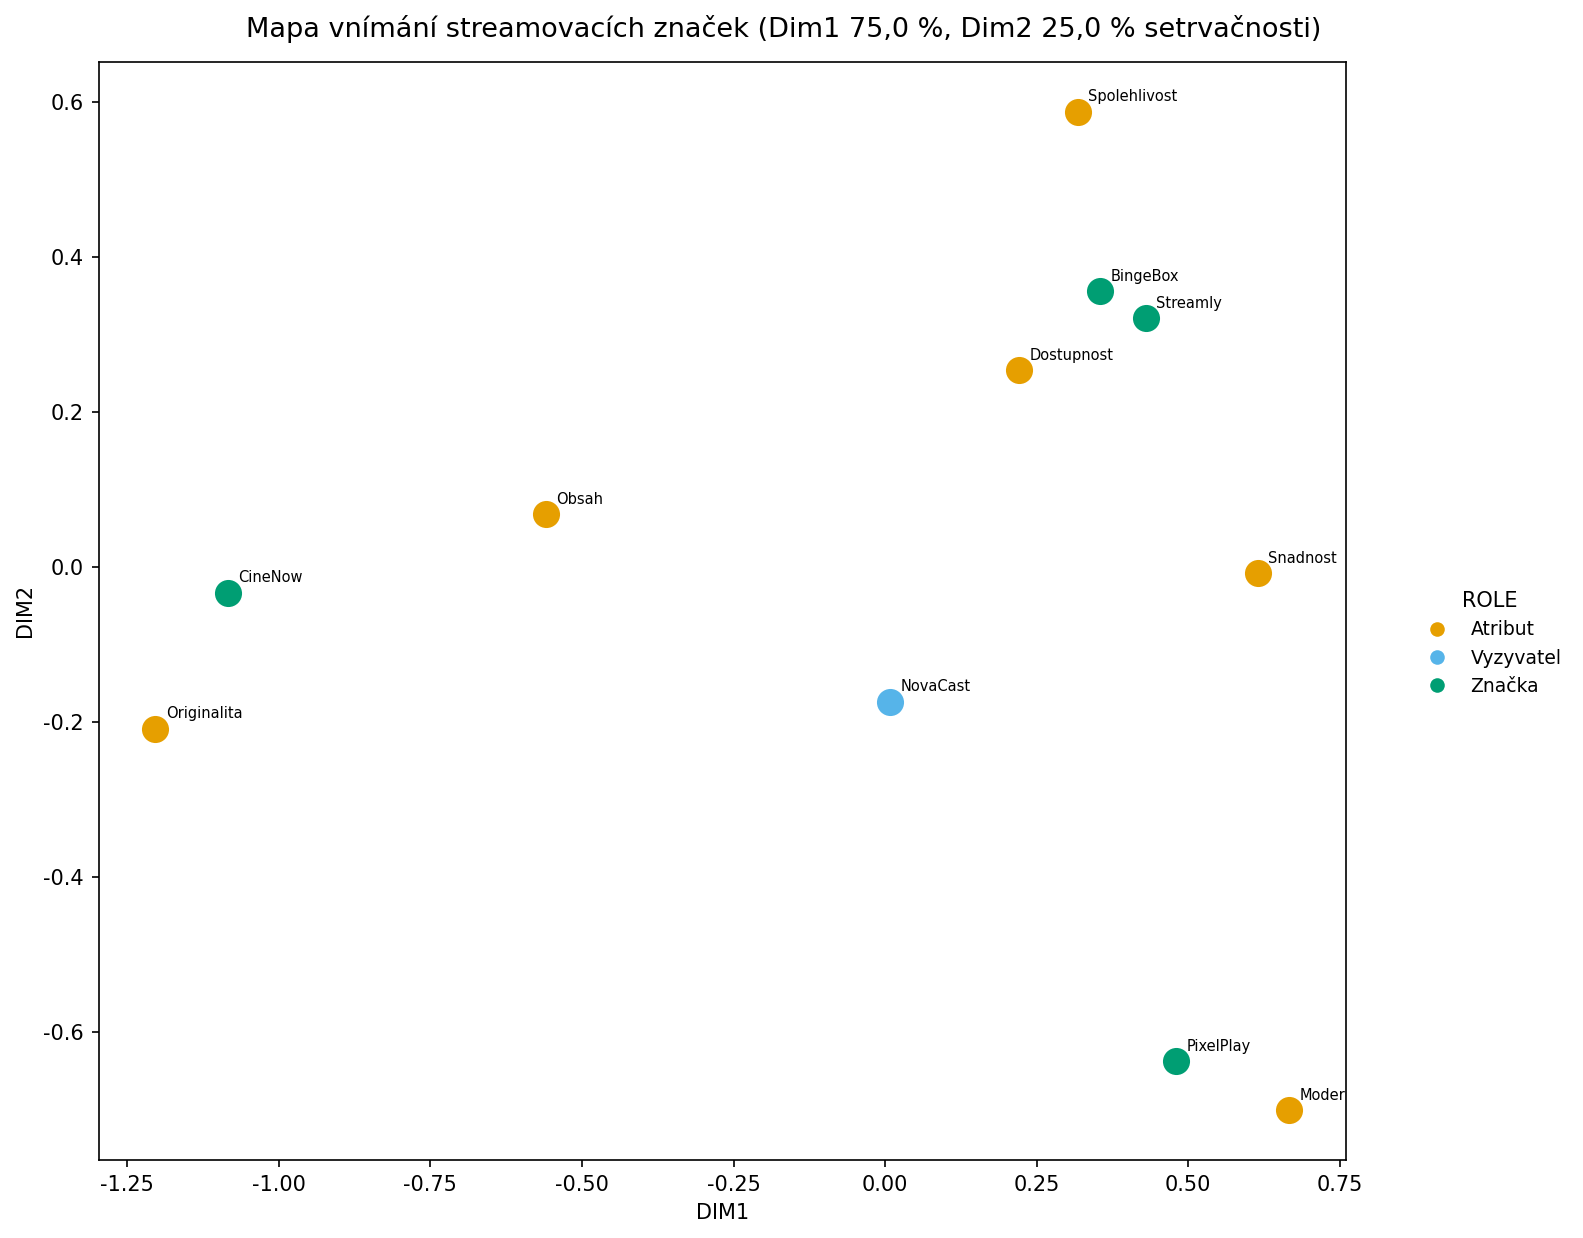

In [6]:
/* Označí každý bod OUTC podle role pro čistou barevnou legendu.
   Doplňkový NovaCast se zapisuje do OUTC s _TYPE_='ROW',
   proto ho zvlášť ošetříme jako Vyzyvatele. */
data ca_map;
    NASTAVIT ca_coords_sup;
    DÉLKA Role $12;
    KDYŽ _NAME_ = 'NovaCast' PAK Role = 'Vyzyvatel';
    JINAK KDYŽ _TYPE_ = 'ROW' PAK Role = 'Značka';
    JINAK Role = 'Atribut';
    PONECHAT Role _NAME_ Dim1 Dim2;
SPUSTIT;

/* Nastaví název mapy globálně před PROC, aby pojmenoval tento
   graf (globální TITLE řídí nadpis ODS grafiky). */
NÁZEV 'Mapa vnímání streamovacích značek (Dim1 75,0 %, Dim2 25,0 % setrvačnosti)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP nemá v tomto sestavení nativní ODS mapu, proto
   symetrické souřadnice vykreslíme pomocí PROC SGSCATTER, který
   každý bod popíše. */
PROCEDURA SGSCATTER data=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
SPUSTIT;

ODS GRAPHICS OFF;
NÁZEV;

## Interpretace výsledků

**Asociace je reálná a plně zachycená.** Chí-kvadrátový test (63,15 při 15 df, p < 0,0001; Cramérovo V = 0,4588) zamítá nezávislost a dvě dimenze CA vysvětlují **100 %** inercie tabulky (75,0 % + 25,0 %), takže mapa níže je úplným shrnutím, nikoli ztrátovou projekcí.

**Tři percepční území.** Při společném čtení souřadnic a mapy:

- **Prémiový obsah (vlevo).** *CineNow* (Dim1 = -1,0847) je táhnut daleko doleva   atributy *Original_Shows* (-1,2037) a *Content_Depth* (-0,5594) — vlastní   vnímání hloubky katalogu.
- **Hodnota a spolehlivost (vpravo nahoře).** *Streamly* (0,4304, 0,3207) a *BingeBox*   (0,3547, 0,3555) se shlukují s *Affordable* (0,2207, 0,2542) a *Reliable* (0,3183,   0,5874) — spolehlivá dvojice s dobrým poměrem cena/výkon.
- **Trendy (vpravo dole).** *PixelPlay* (0,4804, -0,6374) sedí vedle *Trendy*   (0,6671, -0,7003) — mladistvá, momentálně populární značka.

**Doplňkový vyzyvatel.** Promítnut bez ovlivnění os, **NovaCast** přistává na (0,0084, -0,1735) — v podstatě v počátku, přisunut ke straně Trendy / Easy_to_Use. Pro mediálního stratéga je to hlavní zpráva: vyzyvatel zatím nemá žádnou výraznou hodnotu značky a odplouvá do trendy území PixelPlay, takže je namístě vyhraněné positioning (spíše než napodobující).

**Výhrady.** Korespondenční analýza je deskriptivní, nikoli inferenční — vzdálenosti jsou přibližné a *znaménka* os jsou arbitrární (zrcadlové převrácení kterékoli osy je táž mapa). Se pouhými 100 asociacemi respondent-atribut jsou dvě buňky nulové (CineNow x Easy_to_Use, Streamly x Original_Shows), což vyostřuje extrémy; produkční studie by nabrala větší vzorek. Mapu vždy párujte s tabulkou inercie, abyste potvrdili, jakou část asociace zobrazené dimenze vysvětlují.